In [27]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Cell 2 — Load Dataset
df = pd.read_csv("../data/online_retail.csv")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
# Cell 3 — Basic Information about Dataset 
print("Shape:", df.shape)
df.info()

Shape: (541909, 8)
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 69.3 MB


In [ ]:
# Cell 4 — Missing Values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [ ]:
# Cell 5 — Duplicate Records
df.duplicated().sum()

np.int64(5268)

In [9]:
## DATA CLEANING

# Cell 6 — Remove Duplicates
df = df.drop_duplicates()
print(df.shape)

(536641, 8)


In [10]:
# Cell 7 — Remove Missing CustomerID
df = df.dropna(subset=['CustomerID'])
print(df.shape)

(401604, 8)


CustomerID is essential because : Customer Segmentation & Recommendation System both require customer information.

In [11]:
# Cell 8 — Check Missing Values Again
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [ ]:
# Cell 9 — Remove Cancelled Orders

df['InvoiceNo'] = df['InvoiceNo'].astype(str)
cancelled = df[df['InvoiceNo'].str.startswith('C')]
print(cancelled.shape)

(8872, 8)


In this dataset : InvoiceNo starts with C means order was cancelled.

Example : C536379 , C536383
We must remove them.

In [13]:
df = df[~df['InvoiceNo'].str.startswith('C')]
print(df.shape)

(392732, 8)


In [14]:
# Cell 10 — Check Negative Quantities
(df['Quantity'] <= 0).sum()

np.int64(0)

In [ ]:
# Cell 11 — Check Negative or Zero Prices
(df['UnitPrice'] <= 0).sum()

np.int64(40)

In retail datasets :

Negative Quantity means Return, Refund, Correction

UnitPrice = 0 means Free sample, Data issue, Promotional item

In [16]:
# Cell 12 — Remove Invalid Prices
df = df[df['UnitPrice'] > 0]
print(df.shape)

(392692, 8)


In [17]:
# Cell 13 — Create Revenue Feature
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [18]:
# Verify Revenue Feature
df[['Quantity','UnitPrice','TotalPrice']].head()

,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [ ]:
## EDA 1 — Top Countries by Transactions

# Cell 14 — Count Transactions by Country
country_orders = df.groupby('Country')['InvoiceNo'].nunique()
country_orders = country_orders.sort_values(ascending=False)
country_orders.head(10)


Country
United Kingdom    16646
Germany             457
France              389
EIRE                260
Belgium              98
Netherlands          94
Spain                90
Australia            57
Portugal             57
Switzerland          51
Name: InvoiceNo, dtype: int64

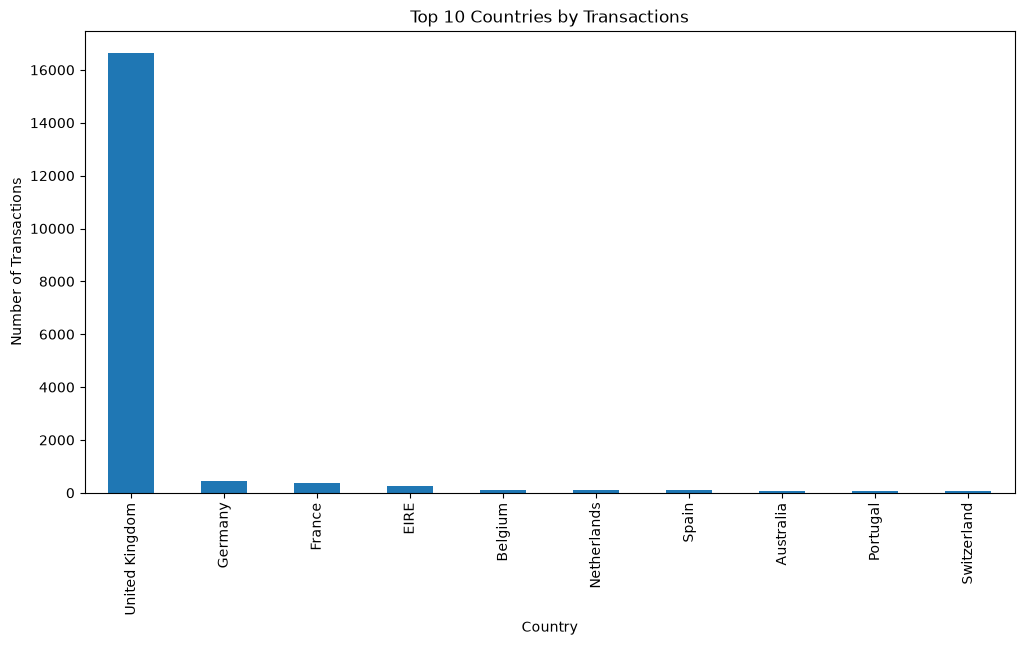

In [ ]:
# Cell 15 — Plot Top Countries
plt.figure(figsize=(12,6))
country_orders.head(10).plot(kind='bar')

plt.title("Top 10 Countries by Transactions")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")

plt.show()

*Top Countries by Transactions*

United Kingdom : 16646 , Germany : 457 , France : 389 , EIRE : 260

**Observation : United Kingdom dominates the customer base and transaction volume. Most sales are concentrated in the UK, indicating that the business primarily operates in the UK market**

In [22]:
## EDA 2 — Top Selling Products

# Cell 16 — Count Transactions by Product
top_products = df.groupby('Description')['Quantity'].sum()
top_products = top_products.sort_values(ascending=False)
top_products.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

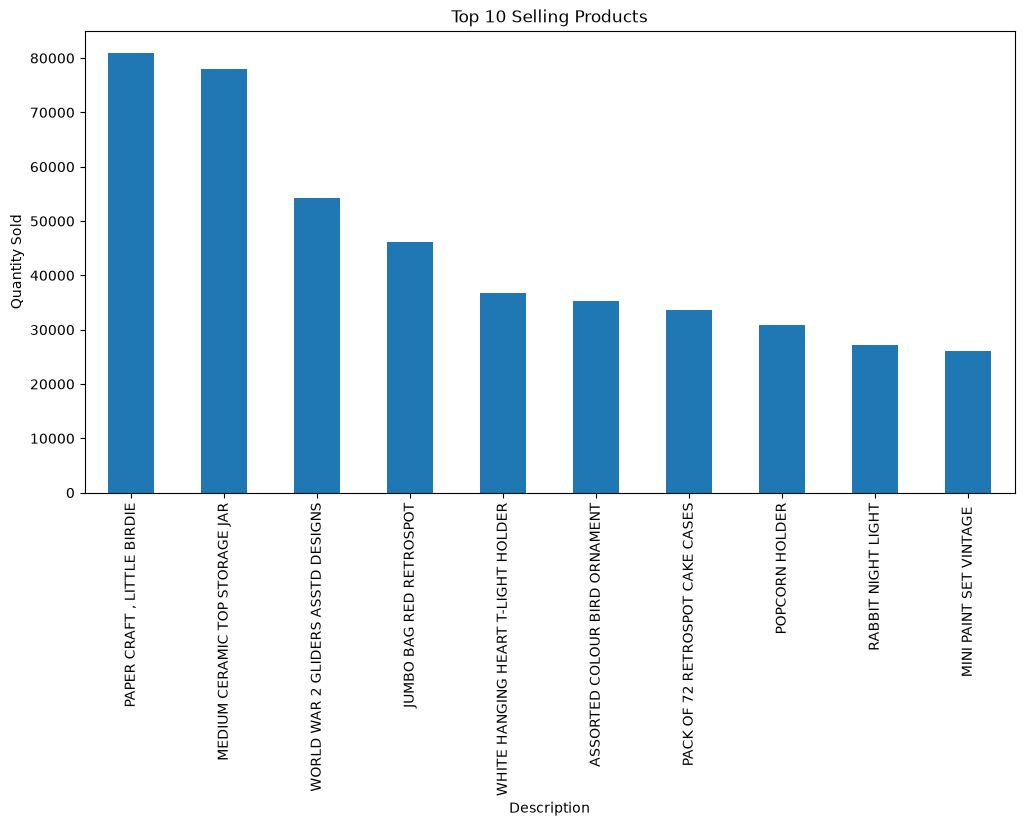

In [23]:
# Cell 17 — Plot Top Selling Products
plt.figure(figsize=(12,6))

top_products.head(10).plot(kind='bar')

plt.title("Top 10 Selling Products")
plt.ylabel("Quantity Sold")

plt.show()

*Top Selling Products*

PAPER CRAFT , LITTLE BIRDIE
, MEDIUM CERAMIC TOP STORAGE JAR
, WORLD WAR 2 GLIDERS ASSTD DESIGNS

**Observation : Certain products contribute disproportionately to sales volume, suggesting strong customer preference and potential candidates for recommendation systems**

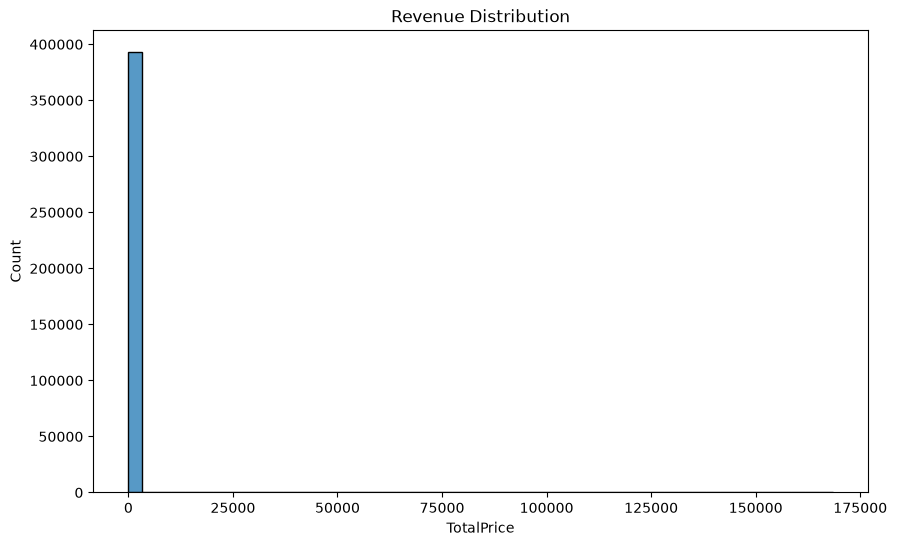

In [24]:
## EDA 3 — Revenue Distribution

# Cell 18 — Plot Revenue Distribution

plt.figure(figsize=(10,6))
sns.histplot(df['TotalPrice'], bins=50)
plt.title("Revenue Distribution")

plt.show()

Histogram is extremely right-skewed.

**Observation : Most transactions are low-value purchases, while a small number of transactions generate very high revenue. This indicates the presence of high-spending customers and outliers**

In [25]:
df = df[df['UnitPrice'] > 0]

print(df.shape)

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

(392692, 9)


In [26]:
country_orders.head(10)

top_products.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

In [ ]:
## ML PART

# Cell 19 — Convert InvoiceDate
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['InvoiceDate'].head()

0   2022-12-01 08:26:00
1   2022-12-01 08:26:00
2   2022-12-01 08:26:00
3   2022-12-01 08:26:00
4   2022-12-01 08:26:00
Name: InvoiceDate, dtype: datetime64[us]

In [28]:
# Cell 20 — RFM Analysis ( Create RFM Table )
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


For every customer :

**Recency -> How many days since last purchase**

*Example*: 2 days , 15 days , 100 days
            Smaller = Better

**Frequency -> Number of purchases**
            Higher = Better

**Monetary -> Total amount spent**
            Higher = Better

In [ ]:
print(rfm.shape) # Check RFM Shape

(4338, 3)


4338 unique customers

In [ ]:
rfm.describe()  # Basic Statistics

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


**Recency**
Min = 1 day # Some customers purchased yesterday.
Max = 374 days # Some customers haven't purchased for over a year.

**Frequency**
Average ≈ 4 purchases
Most customers buy very few times.

**Monetary**
Maximum = ₹280,206 equivalent
Huge spending variation. 

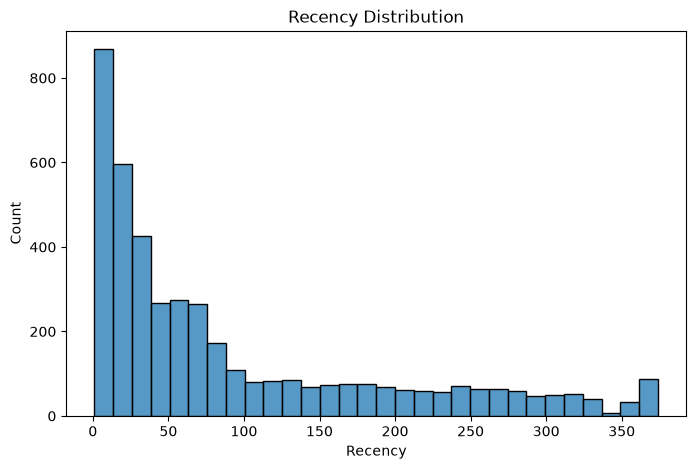

In [ ]:
# Cell 20 - RFM Distribution Plots

## Recency
plt.figure(figsize=(8,5))
sns.histplot(rfm['Recency'], bins=30)

plt.title("Recency Distribution")
plt.show()

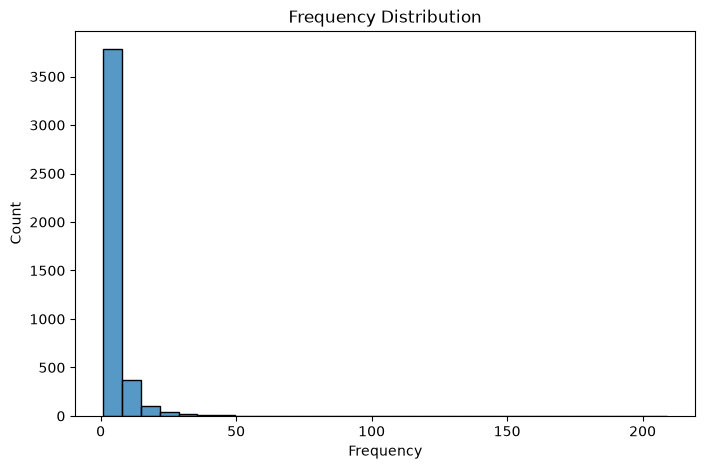

In [32]:
## Frequency
plt.figure(figsize=(8,5))
sns.histplot(rfm['Frequency'], bins=30)

plt.title("Frequency Distribution")
plt.show()

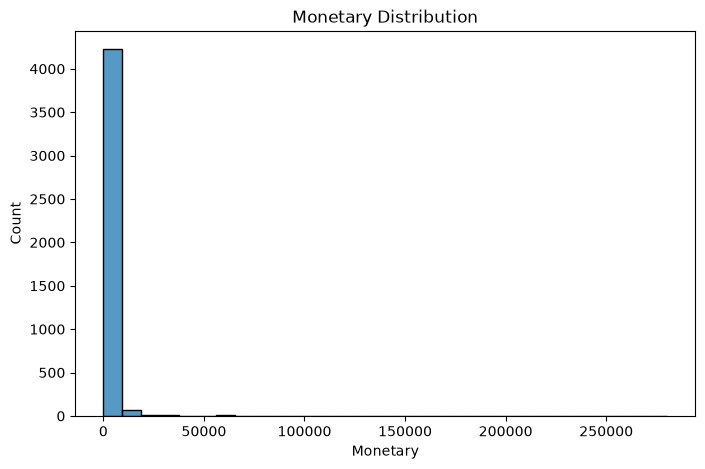

In [33]:
## Monetary
plt.figure(figsize=(8,5))
sns.histplot(rfm['Monetary'], bins=30)

plt.title("Monetary Distribution")
plt.show()

Before KMeans, handle outliers.

The Frequency and Monetary plots clearly show extreme skew.

If we directly apply KMeans : High spenders dominate clustering & clusters become poor.

In [34]:
# Cell 21 - Log Transformation
rfm_log = rfm.copy()

rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

rfm_log.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,5.789960,0.693147,11.253955
12347.0,1.098612,2.079442,8.368925
12348.0,4.330733,1.609438,7.494564
12349.0,2.995732,0.693147,7.472245
12350.0,5.739793,0.693147,5.815324


Without log :

10
100
1000
10000

After log :

2.3
4.6
6.9
9.2

Much better for clustering.

In [35]:
# Cell 22 - Standardization ( StandardScaler )
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled.shape

(4338, 3)

In [36]:
# Cell 23 - KMeans Clustering ( Elbow Method )
inertia = []

for k in range(1,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

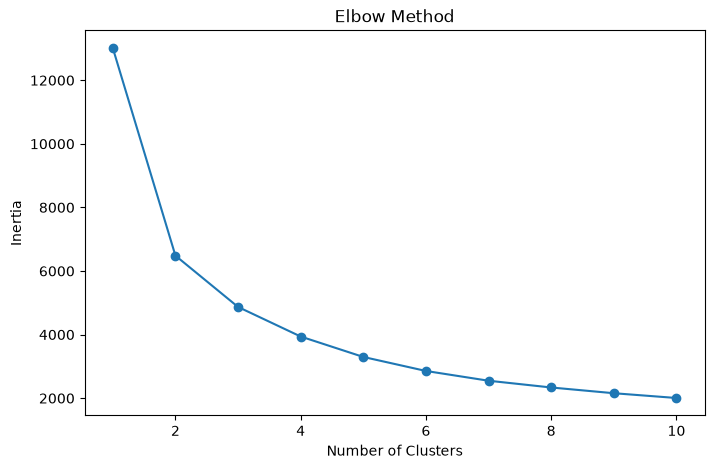

In [37]:
# Plot Elbow Curve
plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

**Elbow Method**

The elbow is clearly around : K = 3 or K = 4

After K=4 the inertia reduction becomes much smaller.

In [38]:
# Cell 24 - KMeans Clustering ( Silhouette Score )
for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(
        rfm_scaled,
        labels
    )

    print(f"K={k} | Silhouette Score={score:.4f}")

K=2 | Silhouette Score=0.4328
K=3 | Silhouette Score=0.3365
K=4 | Silhouette Score=0.3375
K=5 | Silhouette Score=0.3162
K=6 | Silhouette Score=0.3124
K=7 | Silhouette Score=0.3092
K=8 | Silhouette Score=0.3033
K=9 | Silhouette Score=0.2811
K=10 | Silhouette Score=0.2767


**Silhouette Scores**
K=2  → 0.4328  (highest)

In [10]:
# Cell 25 - KMeans Clustering ( Fit Model ) Final KMEans Model
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,0
12347.0,2,182,4310.00,2
12348.0,75,31,1797.24,0
12349.0,19,73,1757.55,0
12350.0,310,17,334.40,3


*Which K should we choose?*

Silhouette says : K = 2 is best.

The Internship given PDF explicitly wants : High-Value, Regular, Occasional, At-Risk
 means : 4 customer segments

So for this internship : Choosing K = 4

**Although K=2 achieved the highest silhouette score, K=4 was selected because it provides more meaningful business segmentation and aligns with the project objective of identifying High-Value, Regular, Occasional, and At-Risk customers**

In [ ]:
# Cell 26 - Cluster Counts
rfm['Cluster'].value_counts()

Cluster
3    1382
0    1222
1     870
2     864
Name: count, dtype: int64

In [12]:
# Cell 27 - Cluster Profiling
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean'
}).round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,95.91,79.12,1513.09
1,19.69,38.27,612.66
2,12.95,280.15,7053.14
3,185.17,14.96,297.60


1. Low Recency + High Frequency + High Monetary
= High Value

2. High Recency + Low Frequency + Low Monetary
= At Risk

3. Low Frequency + Low Monetary
= Occasional

4. Medium Everything
= Regular



**Cluster 2** *(High-Value Customers)*

- Recency = 12.95 (excellent)

- Frequency = 280.15 (highest)

- Monetary = 7053.14 (highest)

**Cluster 3** *(At-Risk Customers)*

- Recency = 185.17 (worst)

- Frequency = 14.96

- Monetary = 297.60 (lowest)

**Cluster 1** *(Regular Customers)*

- Recency = 19.69

- Frequency = 38.27

- Monetary = 612.66

- Good recent activity but moderate spending.

**Cluster 0** *(Occasional Customers)*

- Recency = 95.91

- Frequency = 79.12

- Monetary = 1513.09

- Decent spenders but not as strong as Cluster 2.

In [14]:
# Cell 28 - Create Labels
segment_map = {
    0: 'Occasional',
    1: 'Regular',
    2: 'High-Value',
    3: 'At-Risk'
}

rfm['Segment'] = rfm['Cluster'].map(segment_map)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,0,Occasional
12347.0,2,182,4310.00,2,High-Value
12348.0,75,31,1797.24,0,Occasional
12349.0,19,73,1757.55,0,Occasional
12350.0,310,17,334.40,3,At-Risk


In [15]:
# Check Segment Counts
rfm['Segment'].value_counts()

Segment
At-Risk       1382
Occasional    1222
Regular        870
High-Value     864
Name: count, dtype: int64

In [16]:
# Create Segment Summary Table
segment_summary = rfm.groupby('Segment').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean'
}).round(2)

segment_summary

,Recency,Frequency,Monetary
Segment,,,
At-Risk,185.17,14.96,297.60
High-Value,12.95,280.15,7053.14
Occasional,95.91,79.12,1513.09
Regular,19.69,38.27,612.66


In [25]:
# Cell 26 - PCA Cluster Visualization
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

pca_df = pd.DataFrame(
    rfm_pca,
    columns=['PCA1','PCA2']
)

pca_df['Segment'] = rfm['Segment'].values

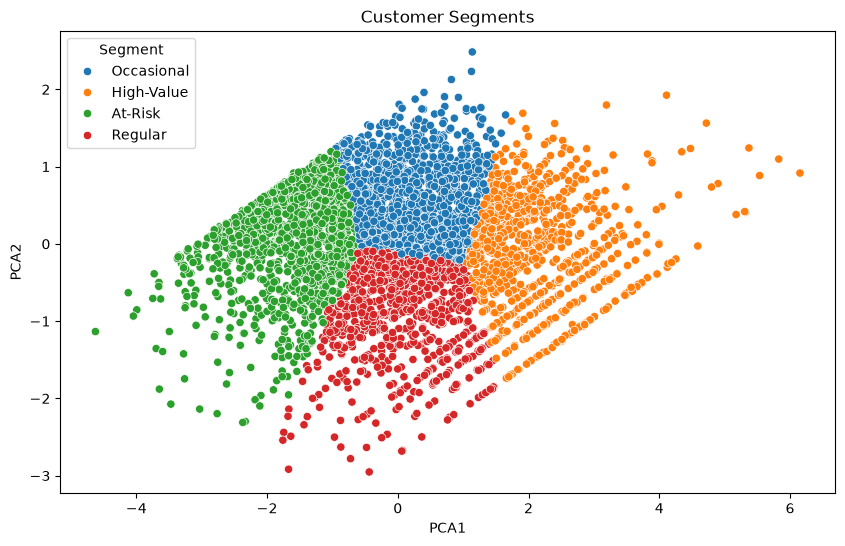

In [28]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x='PCA1',
    y='PCA2',
    hue='Segment'
)

plt.title("Customer Segments")
plt.show()

**Principal Component Analysis (PCA) was applied to reduce the three-dimensional RFM feature space into two dimensions for visualization. The scatter plot demonstrates that customers were successfully grouped into four distinct clusters using K-Means clustering. Each cluster represents a unique customer behavior pattern based on Recency, Frequency, and Monetary values.**

Based on your cluster profiling :

| Segment        | Characteristics                                                           |
| -------------- | ------------------------------------------------------------------------- |
| **High-Value** | Recent purchases, highest frequency, highest spending                     |
| **Regular**    | Active customers with moderate spending and purchase frequency            |
| **Occasional** | Customers who purchase periodically but spend less than premium customers |
| **At-Risk**    | Customers with long inactivity periods and low spending                   |


In [29]:
## Recommendation System

# Cell 26 - Create Customer-Product Matrix
customer_product_matrix = df.pivot_table(
    index='CustomerID',
    columns='Description',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)

customer_product_matrix.shape

(4338, 3877)

In [30]:
# Cell 27 - Create Product-Customer Matrix (Transpose Matrix)
product_customer_matrix = customer_product_matrix.T
product_customer_matrix.shape

(3877, 4338)

In [32]:
# Cell 28 - Product Similarity Matrix (Cosine Similarity)
from sklearn.metrics.pairwise import cosine_similarity

product_similarity = cosine_similarity(
    product_customer_matrix
)

product_similarity.shape

(3877, 3877)

**Matrix Shapes**

Customer-Product Matrix : (4338, 3877)

Product-Customer Matrix : (3877, 4338)

Similarity Matrix       : (3877, 3877)

This means:

- 4,338 customers
- 3,877 products
- Similarity calculated between every product pair

In [33]:
# Cell 29 - Create Product Similarity DataFrame
similarity_df = pd.DataFrame(
    product_similarity,
    index=product_customer_matrix.index,
    columns=product_customer_matrix.index
)

similarity_df.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
Description,,,,,,,,,,,,,,,,,,,,,
4 PURPLE FLOCK DINNER CANDLES,1.000000,0.000000,0.000021,0.000228,0.000000,0.000000,0.020228,0.000000,0.000263,0.063543,...,0.0,0.001376,0.015917,0.001771,0.0,0.002852,0.0,0.013155,0.000000,0.002599
50'S CHRISTMAS GIFT BAG LARGE,0.000000,1.000000,0.003534,0.004001,0.000000,0.020230,0.027477,0.902593,0.119038,0.013384,...,0.0,0.001726,0.015572,0.018032,0.0,0.015710,0.0,0.011238,0.000000,0.029793
DOLLY GIRL BEAKER,0.000021,0.003534,1.000000,0.870965,0.980574,0.006358,0.005311,0.003040,0.001764,0.411471,...,0.0,0.000044,0.002869,0.344928,0.0,0.525868,0.0,0.822964,0.000097,0.006665
I LOVE LONDON MINI BACKPACK,0.000228,0.004001,0.870965,1.000000,0.883987,0.020076,0.004912,0.004051,0.008249,0.382226,...,0.0,0.001416,0.004198,0.310053,0.0,0.471772,0.0,0.749303,0.000000,0.010394
I LOVE LONDON MINI RUCKSACK,0.000000,0.000000,0.980574,0.883987,1.000000,0.000000,0.000000,0.000000,0.000000,0.410712,...,0.0,0.000000,0.000000,0.347021,0.0,0.530836,0.0,0.837176,0.000000,0.000000


In [34]:
# Cell 30 - Product Recommendation Function
def recommend_products(product_name, n=5):

    product_name = product_name.upper()

    matches = [
        p for p in similarity_df.index
        if product_name in p.upper()
    ]

    if len(matches) == 0:
        return "Product not found"

    selected_product = matches[0]

    recommendations = (
        similarity_df[selected_product]
        .sort_values(ascending=False)
        .iloc[1:n+1]
    )

    return recommendations.index.tolist()

In [ ]:
# Cell 31 - Test 1 Recommendation Function
recommend_products("WHITE HANGING HEART T-LIGHT HOLDER")

['GIN + TONIC DIET METAL SIGN',
 'RED HANGING HEART T-LIGHT HOLDER',
 'WASHROOM METAL SIGN',
 'LAUNDRY 15C METAL SIGN',
 'GREEN VINTAGE SPOT BEAKER']

In [ ]:
recommend_products("JUMBO BAG RED RETROSPOT") # Test 2 Recommendation Function

['JUMBO BAG STRAWBERRY',
 'JUMBO BAG PINK POLKADOT',
 'JUMBO BAG OWLS',
 'JUMBO BAG PINK VINTAGE PAISLEY',
 'JUMBO BAG APPLES']

This is actually a very good recommendation result because all products belong to the same "JUMBO BAG" category

In [ ]:
# Cell 32 - Save Models

import joblib

joblib.dump(kmeans, "../models/customer_segmentation_model.pkl")

joblib.dump(
    similarity_df,
    "../models/product_similarity.pkl"
)

['../models/product_similarity.pkl']

In [38]:
import os

os.listdir("../models")

['customer_segmentation_model.pkl', 'product_similarity.pkl']

*Model Evaluation & Insights* :-

 
**Customer Segmentation Insights**
- High-Value customers generate the highest revenue.
- At-Risk customers have not purchased recently and require retention strategies.
- Regular customers contribute stable revenue.
- Loyal customers purchase frequently and should receive loyalty rewards.

**Recommendation System Insights**
- Item-based collaborative filtering successfully identifies related products.
- Cosine similarity recommends products frequently purchased together.
- Can be used for cross-selling and upselling.